In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
%matplotlib inline

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = sns.load_dataset('titanic').dropna(subset=['age', 'embarked'])

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 120],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

print('Dataset shape:', df.shape)

Dataset shape: (712, 16)


In [ ]:
df['age_group'].head()

,age_group
0,Young Adult
1,Adult
2,Young Adult
3,Young Adult
4,Young Adult


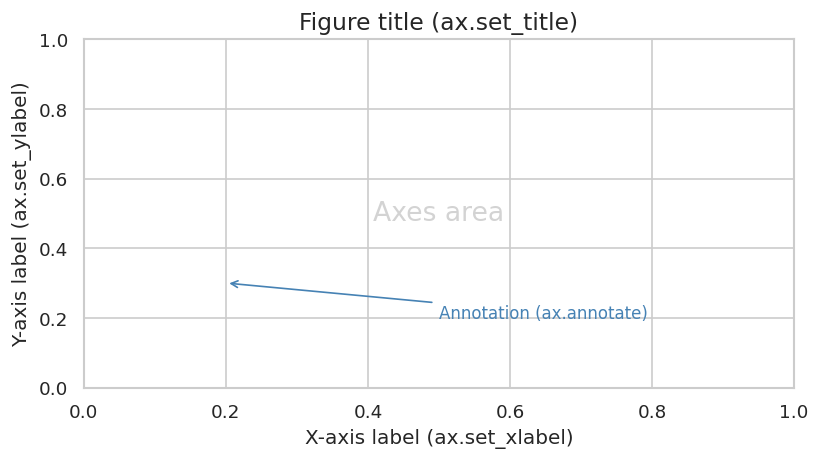

In [ ]:
# Anatomy demo — labelled blank figure

fig, ax = plt.subplots(figsize=(7, 4))

ax.set_title('Figure title (ax.set_title)', fontsize=14)

ax.set_xlabel('X-axis label (ax.set_xlabel)')
ax.set_ylabel('Y-axis label (ax.set_ylabel)')

ax.text(
    0.5, 0.5,
    'Axes area',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=16,
    color='lightgray'
)

# Annotation arrow

ax.annotate(
    'Annotation (ax.annotate)',
    xy=(0.2, 0.3),
    xycoords='axes fraction',
    xytext=(0.5, 0.2),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', color='steelblue'),
    color='steelblue',
    fontsize=10
)

plt.tight_layout()

plt.show()

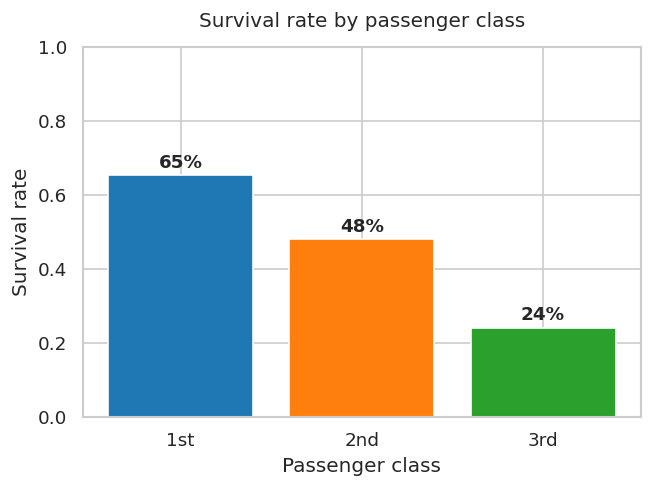

In [ ]:
# Part 2 - Chart 1: Bar chart

# Best for comparing a numeric value across discrete categories

survival_by_class = df.groupby('pclass')['survived'].mean().reset_index()

survival_by_class.columns = ['Class', 'Survival Rate']

survival_by_class['Class'] = survival_by_class['Class'].map({
    1: '1st',
    2: '2nd',
    3: '3rd'
})

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    survival_by_class['Class'],
    survival_by_class['Survival Rate'],
    color=['tab:blue', 'tab:orange', 'tab:green']
)

# Add data labels on top of each bar

for bar, val in zip(bars, survival_by_class['Survival Rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.0%}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title('Survival rate by passenger class', pad=12)

ax.set_xlabel('Passenger class')

ax.set_ylabel('Survival rate')

ax.set_ylim(0, 1)

plt.show()

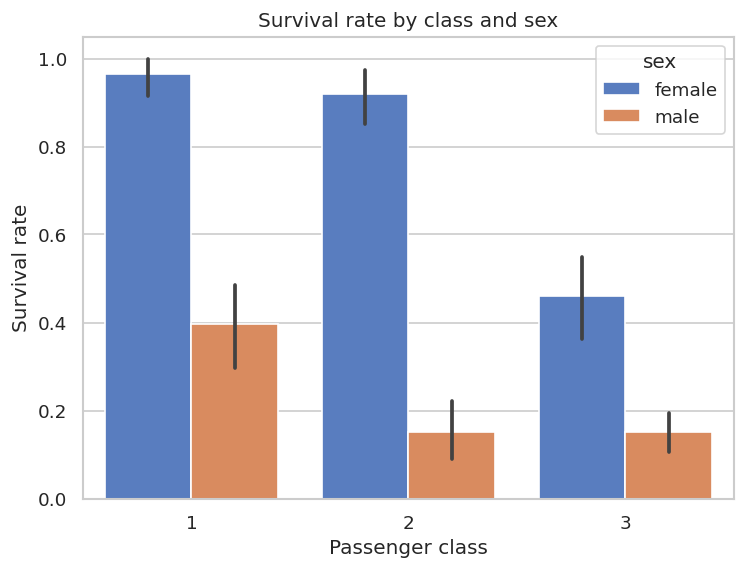

In [ ]:
# Create a grouped bar chart showing survival rate by BOTH class and sex

# Hint: use sns.barplot with x='pclass', hue='sex', y='survived'

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    hue='sex'
)

plt.title('Survival rate by class and sex')

plt.xlabel('Passenger class')

plt.ylabel('Survival rate')

plt.show()

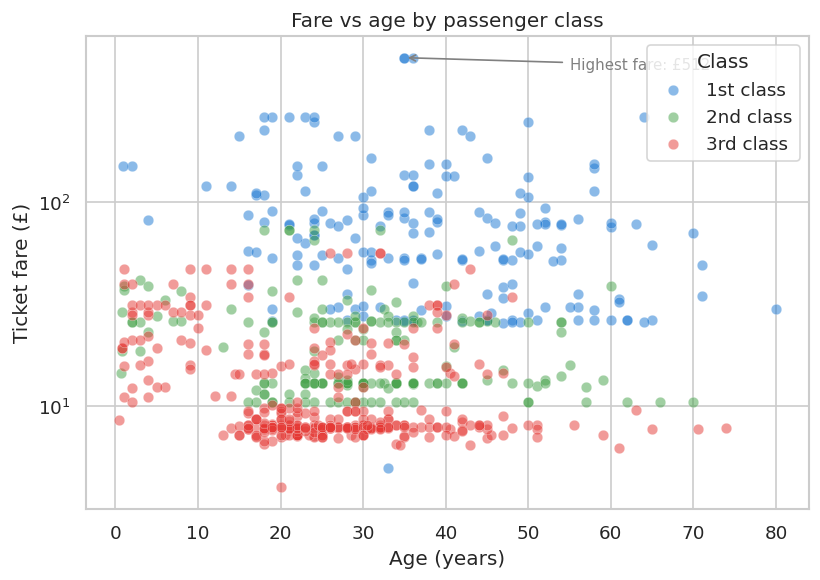

In [ ]:
# Part 3 : Scatter plot

fig, ax = plt.subplots(figsize=(7, 5))

colors = {
    1: '#1976D2',
    2: '#43A047',
    3: '#E53935'
}

labels = {
    1: '1st class',
    2: '2nd class',
    3: '3rd class'
}

for cls in [1, 2, 3]:

    subset = df[df['pclass'] == cls]

    ax.scatter(
        subset['age'],
        subset['fare'],
        c=colors[cls],
        alpha=0.5,
        s=40,
        edgecolors='white',
        linewidth=0.3,
        label=labels[cls]
    )

ax.set_title('Fare vs age by passenger class')

ax.set_xlabel('Age (years)')

ax.set_ylabel('Ticket fare (£)')

ax.legend(title='Class')

ax.set_yscale('log')   # log scale because a few very high fares skew the axis


# Annotate an outlier

max_fare_idx = df['fare'].idxmax()

ax.annotate(
    f'Highest fare: £{df.loc[max_fare_idx, "fare"]:.0f}',

    xy=(
        df.loc[max_fare_idx, 'age'],
        df.loc[max_fare_idx, 'fare']
    ),

    xytext=(55, 450),

    arrowprops=dict(
        arrowstyle='->',
        color='gray'
    ),

    fontsize=9,
    color='gray'
)

plt.tight_layout()

plt.show()

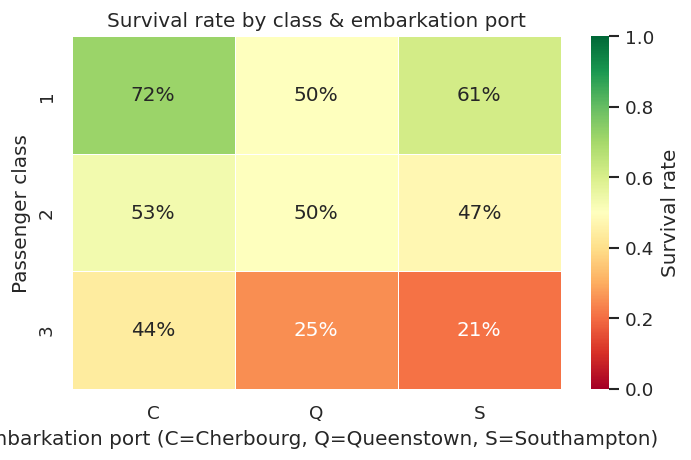

In [ ]:
# Survival rate pivot: class × embarkation port

pivot = df.pivot_table(
    values='survived',
    index='pclass',
    columns='embarked',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Survival rate'}
)

ax.set_title('Survival rate by class & embarkation port')

ax.set_xlabel(
    'Embarkation port (C=Cherbourg, Q=Queenstown, S=Southampton)'
)

ax.set_ylabel('Passenger class')

plt.tight_layout()

plt.show()

# Heat map

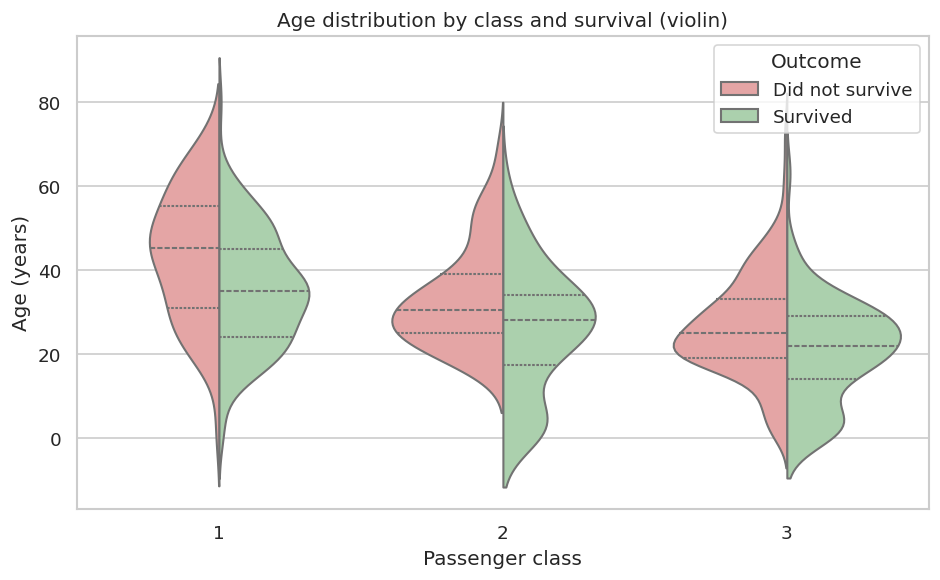

In [ ]:
# Part 5: Violin + Strip Plot using seaborn

fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='pclass',
    y='age',
    hue='survived',
    split=True,
    palette={0: '#EF9A9A', 1: '#A5D6A7'},
    inner='quartile',
    ax=ax
)

ax.set_title('Age distribution by class and survival (violin)')

ax.set_xlabel('Passenger class')

ax.set_ylabel('Age (years)')

handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ['Did not survive', 'Survived'],
    title='Outcome'
)

plt.tight_layout()

plt.show()

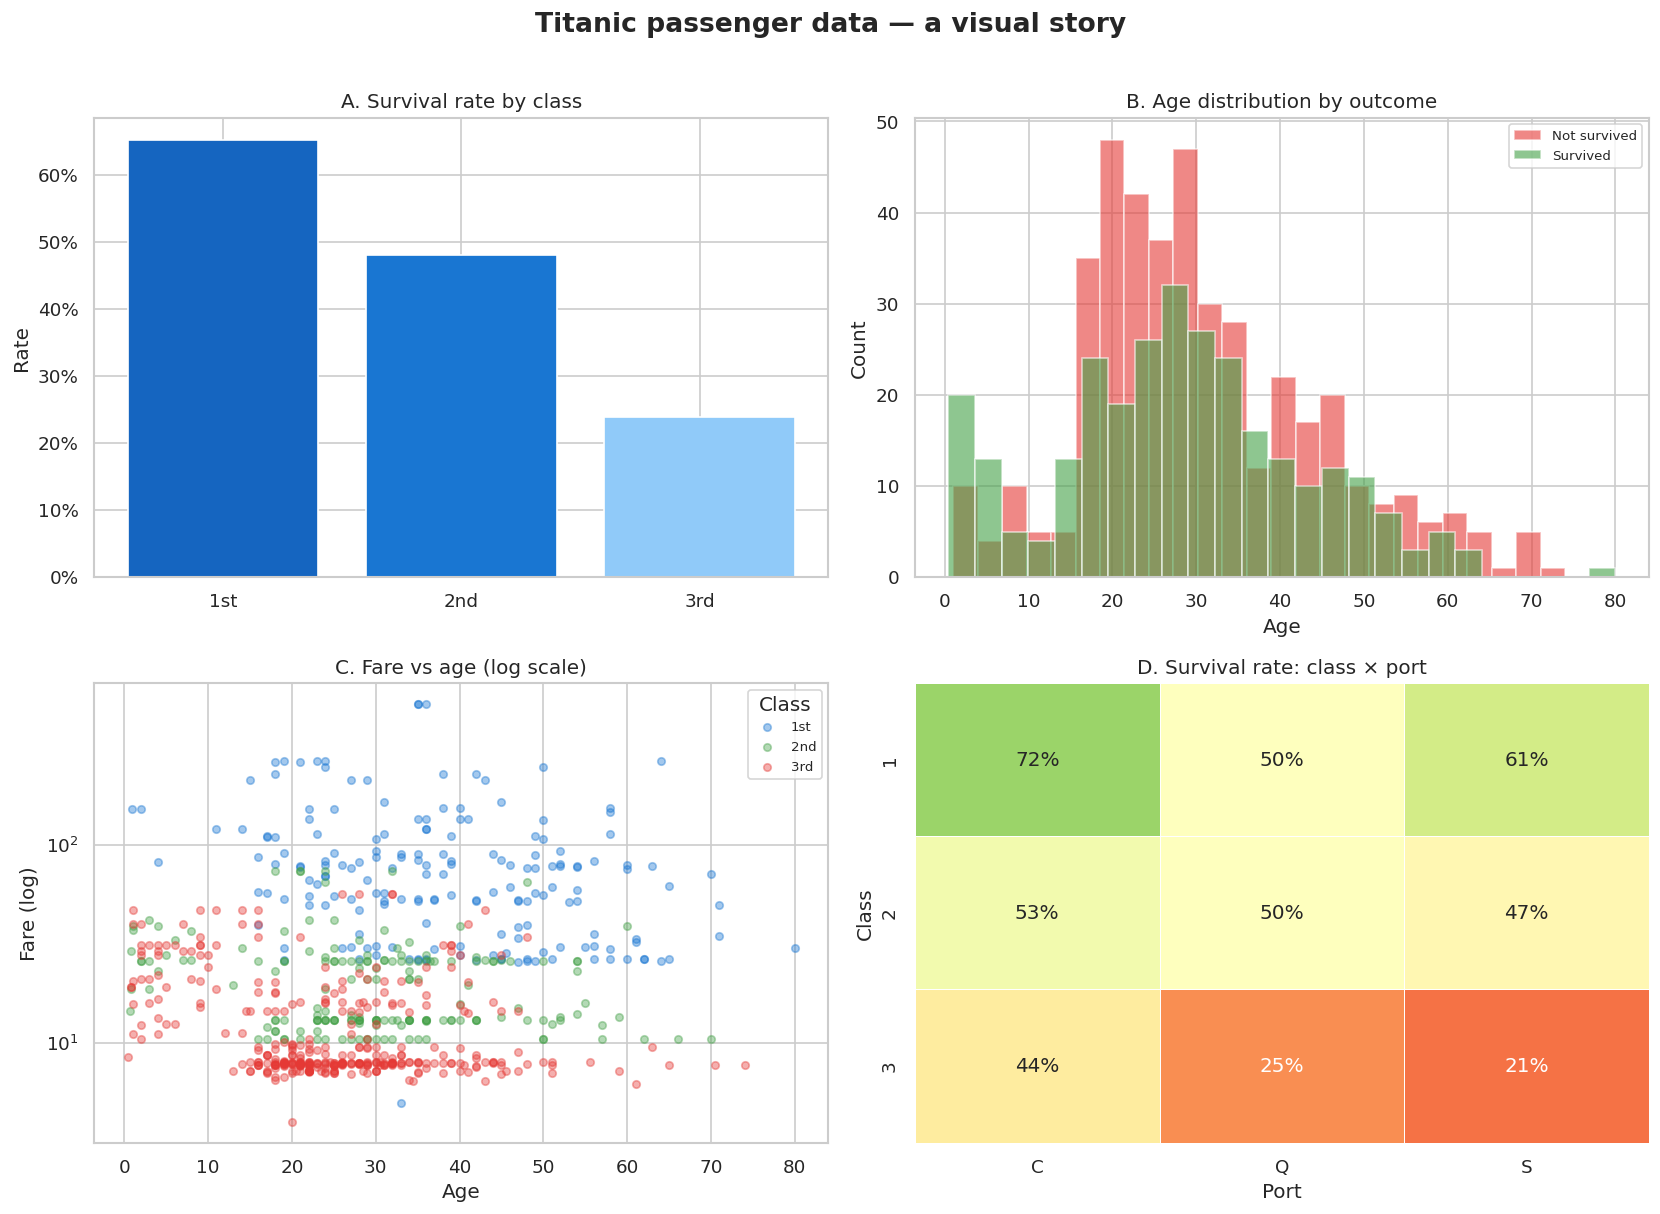

In [ ]:
# Part 6 : Multi-Panel Dashboard with plt.subplots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Titanic passenger data — a visual story',
    fontsize=16,
    fontweight='bold',
    y=1.01
)

# —— Panel A: survival rate by class ——

ax = axes[0, 0]

surv = df.groupby('pclass')['survived'].mean()

ax.bar(
    ['1st', '2nd', '3rd'],
    surv.values,
    color=['#1565C0', '#1976D2', '#90CAF9']
)

ax.set_title('A. Survival rate by class')

ax.set_ylabel('Rate')

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}')
)

# —— Panel B: age histogram ——

ax = axes[0, 1]

ax.hist(
    df[df['survived'] == 0]['age'],
    bins=25,
    alpha=0.6,
    color='#E53935',
    label='Not survived'
)

ax.hist(
    df[df['survived'] == 1]['age'],
    bins=25,
    alpha=0.6,
    color='#43A047',
    label='Survived'
)

ax.set_title('B. Age distribution by outcome')

ax.set_xlabel('Age')

ax.set_ylabel('Count')

ax.legend(fontsize=8)

# —— Panel C: fare vs age scatter ——

ax = axes[1, 0]

for cls, c, lbl in zip(
    [1, 2, 3],
    ['#1976D2', '#43A047', '#E53935'],
    ['1st', '2nd', '3rd']
):

    s = df[df['pclass'] == cls]

    ax.scatter(
        s['age'],
        s['fare'],
        c=c,
        alpha=0.4,
        s=20,
        label=lbl
    )

ax.set_yscale('log')

ax.set_title('C. Fare vs age (log scale)')

ax.set_xlabel('Age')

ax.set_ylabel('Fare (log)')

ax.legend(title='Class', fontsize=8)

# —— Panel D: survival heatmap ——

ax = axes[1, 1]

pivot = df.pivot_table(
    values='survived',
    index='pclass',
    columns='embarked',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1,
    cbar=False
)

ax.set_title('D. Survival rate: class × port')

ax.set_xlabel('Port')

ax.set_ylabel('Class')

plt.tight_layout()

plt.show()

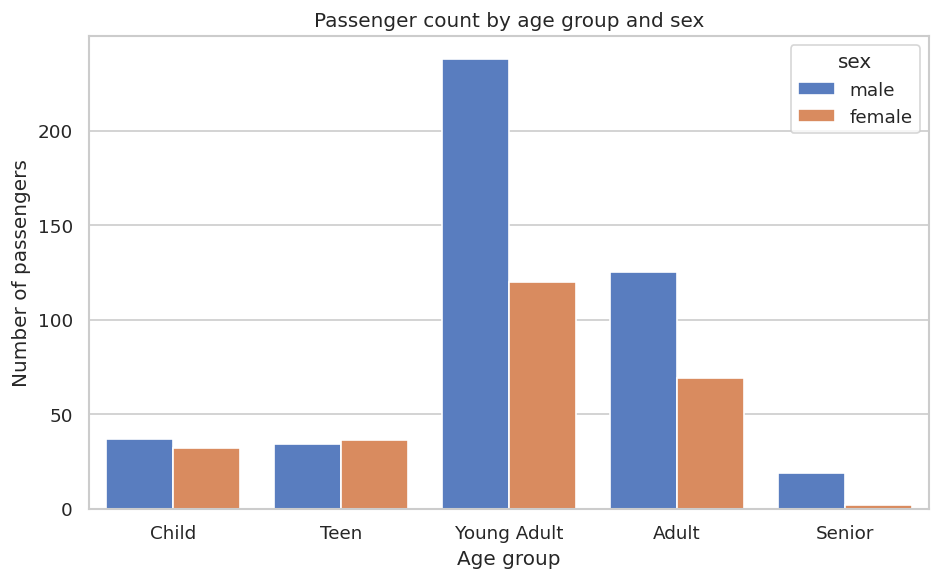

In [ ]:
# Add a fifth panel — a seaborn countplot showing the number of passengers by age_group,
# coloured by sex

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x='age_group',
    hue='sex'
)

ax.set_title('Passenger count by age group and sex')

ax.set_xlabel('Age group')

ax.set_ylabel('Number of passengers')

plt.tight_layout()

# Save the full 5-panel figure as titanic_dashboard.png

plt.savefig('titanic_dashboard.png')

plt.show()

/tmp/ipykernel_3254/1615468122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


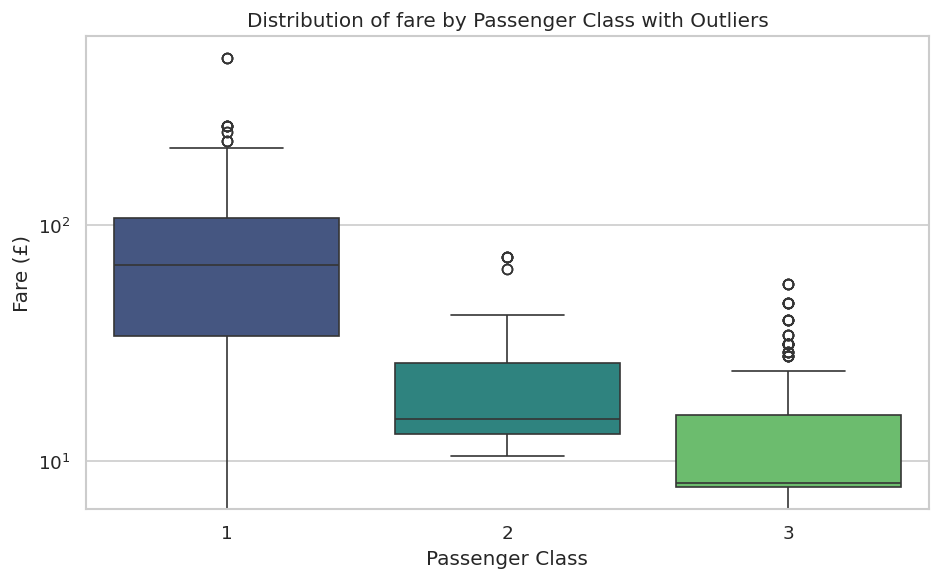

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    x='pclass',
    y='fare',
    data=df,
    palette='viridis',
    ax=ax
)

ax.set_title('Distribution of fare by Passenger Class with Outliers')

ax.set_xlabel('Passenger Class')

ax.set_ylabel('Fare (£)')

ax.set_yscale('log')   # Use log scale for better visualization due to skewed fare data

plt.tight_layout()

plt.show()